In [5]:
# Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/lymphoma_classifier"

Mounted at /content/drive


In [6]:
# Cell 2 — Reinstall dependencies (Colab doesn't remember installs across notebooks)
!pip install openslide-python -q
!apt-get install -y openslide-tools -q

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 42 not upgraded.
Need to get 104 kB of archives.
After this operation, 297 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 openslide-tools amd64 3.4.1+dfsg-5build1 [13.8 kB]
Fetched 104 kB in 1s (108 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-5build1_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-5build1) ...
Selecting previously unselected package openslide-tools.
Preparing to u

In [7]:
# Cell 3 — Confirm patches are accessible
import os
for label in ["burkitt", "dlbcl"]:
    folder = os.path.join(BASE_DIR, "patches", label)
    count = len([f for f in os.listdir(folder) if f.endswith(".png")])
    print(f"{label}: {count} patches")

burkitt: 3278 patches
dlbcl: 4217 patches


Cell 1 — Imports and config (paste and run)


Cell 2 — PatchDataset class (paste and run)


Cell 3 — Transforms and splits (paste and run, share the output — it will show train/val/test counts)


Cell 4 — Model (paste and run, should print Linear(in_features=512, out_features=2, bias=True))


Cell 5 — Training loop (paste and run — this is the big one, will take 20–40 minutes)


Cell 6 — Evaluation (run after training finishes)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

# Config
PATCH_DIR = f"{BASE_DIR}/patches"
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [9]:
class PatchDataset(Dataset):
    def __init__(self, samples, transform=None):
        """
        samples: list of (patch_path, label) tuples
        transform: image augmentations/preprocessing
        """
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx): #loads each patch on demand, one at a time, only when the training loop actually needs it.
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
# Transforms — training gets augmentation, val/test get just normalization
# ImageNet mean/std because ResNet was pretrained on ImageNet
#chains multiple image transformations together into a single pipeline that gets applied to every patch before it enters the model.
#why all the random flipings? Data Augmentation. It artificially inflates your dataset and prevents overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
#normalizing with imageNet mean and std channel by channel (RBG)
#because ResNet is trained on ImageNet and the weights are adjusted for means and std there
#we want evaluation to be deterministic
#You need a fixed, stable benchmark to know if your model is actually improving
# accuracy will change if you flip the image every time
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Build full sample list [(path, label), ...]
label_map = {"burkitt": 0, "dlbcl": 1}
all_samples = []
for label_name, label_idx in label_map.items():
    folder = os.path.join(PATCH_DIR, label_name)
    for fname in os.listdir(folder):
        if fname.endswith(".png"):
            all_samples.append((os.path.join(folder, fname), label_idx))

# Shuffle and split
np.random.seed(42)
np.random.shuffle(all_samples)

n = len(all_samples)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)
n_test = n - n_train - n_val

train_samples = all_samples[:n_train]
val_samples = all_samples[n_train:n_train + n_val]
test_samples = all_samples[n_train + n_val:]

train_dataset = PatchDataset(train_samples, transform=train_transform)
val_dataset = PatchDataset(val_samples, transform=val_test_transform)
test_dataset = PatchDataset(test_samples, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Total patches: {n}")
print(f"  Train: {len(train_dataset)}")
print(f"  Val:   {len(val_dataset)}")
print(f"  Test:  {len(test_dataset)}")

Total patches: 7495
  Train: 5246
  Val:   1124
  Test:  1125


In [11]:
def build_model():
    # Load ResNet18 pretrained on ImageNet
    model = models.resnet18(weights="IMAGENET1K_V1")

    # Replace the final layer for binary classification
    # ResNet18's final layer outputs 1000 classes — we need just 2
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 2)

    return model.to(DEVICE)

model = build_model()
print(model.fc)  # confirm the final layer is now Linear(512 → 2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [ ]:

#this i s patch-level split training , scroll down to slide-lever plit training!
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)  #forward pass
        loss = criterion(outputs, labels)
        loss.backward()  #backward pass
        optimizer.step()
        total_loss += loss.item()  #beacuse loss is a tensor. item gives the float
        #average error per image for that specific batch. so we devide total-loss/len(loader)=num batches
        correct += (outputs.argmax(1) == labels).sum().item()
        #correct doesnt come preaveraged, so we must devide by total
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images) #just forward pass
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

# Training loop
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    scheduler.step()  #reduces the learning rate according to scheduler

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{BASE_DIR}/best_model.pth")
        print(f"  ✓ New best model saved")

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

  ✓ New best model saved
Epoch 1/10 | Train Loss: 0.2226 | Train Acc: 0.9056 | Val Loss: 0.1064 | Val Acc: 0.9680


  ✓ New best model saved
Epoch 2/10 | Train Loss: 0.1180 | Train Acc: 0.9548 | Val Loss: 0.0589 | Val Acc: 0.9822


  ✓ New best model saved
Epoch 3/10 | Train Loss: 0.0747 | Train Acc: 0.9731 | Val Loss: 0.0468 | Val Acc: 0.9875


  ✓ New best model saved
Epoch 4/10 | Train Loss: 0.0419 | Train Acc: 0.9846 | Val Loss: 0.0268 | Val Acc: 0.9929


Epoch 5/10 | Train Loss: 0.0413 | Train Acc: 0.9834 | Val Loss: 0.0359 | Val Acc: 0.9902


Epoch 6/10 | Train Loss: 0.0321 | Train Acc: 0.9880 | Val Loss: 0.0231 | Val Acc: 0.9902


Epoch 7/10 | Train Loss: 0.0250 | Train Acc: 0.9905 | Val Loss: 0.0260 | Val Acc: 0.9929


  ✓ New best model saved
Epoch 8/10 | Train Loss: 0.0217 | Train Acc: 0.9924 | Val Loss: 0.0181 | Val Acc: 0.9938


  ✓ New best model saved
Epoch 9/10 | Train Loss: 0.0185 | Train Acc: 0.9929 | Val Loss: 0.0192 | Val Acc: 0.9947


Epoch 10/10 | Train Loss: 0.0165 | Train Acc: 0.9943 | Val Loss: 0.0173 | Val Acc: 0.9947


Test Accuracy: 0.9973


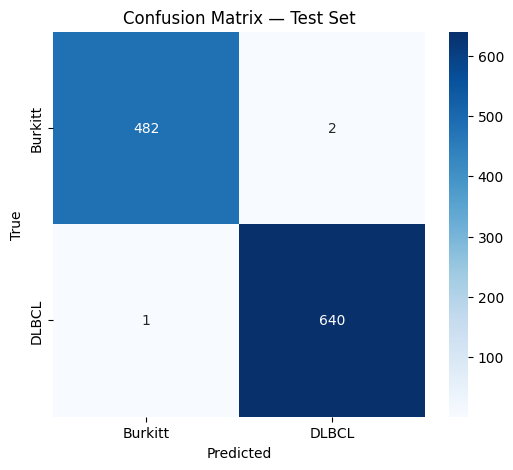

              precision    recall  f1-score   support

     Burkitt       1.00      1.00      1.00       484
       DLBCL       1.00      1.00      1.00       641

    accuracy                           1.00      1125
   macro avg       1.00      1.00      1.00      1125
weighted avg       1.00      1.00      1.00      1125



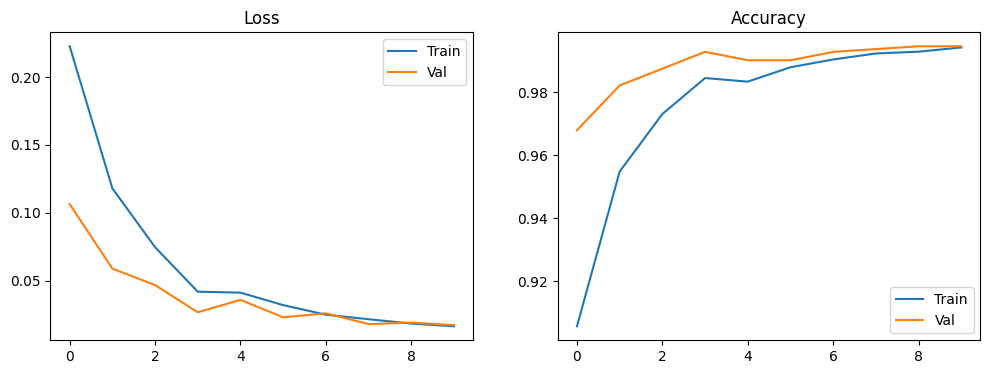

In [ ]:
# Load best model and evaluate on test set, for patch-leverl split training
model.load_state_dict(torch.load(f"{BASE_DIR}/best_model.pth"))
test_loss, test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Burkitt", "DLBCL"],
            yticklabels=["Burkitt", "DLBCL"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.show()

print(classification_report(all_labels, all_preds,
                            target_names=["Burkitt", "DLBCL"]))

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_title("Loss")
ax1.legend()
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_title("Accuracy")
ax2.legend()
plt.show()

**Step 1 — Validate properly with slide-level splits** — ensure no slide appears in both train and test. This is the real test of generalisation

In [14]:
import os
import numpy as np
from collections import defaultdict

PATCH_DIR = f"{BASE_DIR}/patches"

# Step 1 — Extract slide IDs from patch filenames
# Patch names look like: BLGSP-71-06-00288-01-HE.601C04C6_r0012_c0008.png
# The slide name is everything before the last _rXXXX_cXXXX.png

def get_slide_id(fname):
    """Extract slide name from patch filename by stripping _rXXXX_cXXXX.png"""
    # Remove extension
    name = fname.replace(".png", "")
    # Remove the last two underscore-separated parts (row and col)
    parts = name.split("_")
    slide_id = "_".join(parts[:-2])
    return slide_id

# Build a dictionary: slide_id -> list of (patch_path, label)
slide_to_patches = defaultdict(list)

label_map = {"burkitt": 0, "dlbcl": 1}
for label_name, label_idx in label_map.items():
    folder = os.path.join(PATCH_DIR, label_name)
    for fname in os.listdir(folder):
        if fname.endswith(".png"):
            slide_id = get_slide_id(fname)
            patch_path = os.path.join(folder, fname)
            slide_to_patches[slide_id].append((patch_path, label_idx))

# Summarise what we have
print(f"Total unique slides: {len(slide_to_patches)}")
print(f"Total patches: {sum(len(v) for v in slide_to_patches.values())}")
print(f"\nPatches per slide:")
for slide_id, patches in sorted(slide_to_patches.items()):
    label = "burkitt" if patches[0][1] == 0 else "dlbcl"
    print(f"  [{label}] {slide_id[:60]} → {len(patches)} patches")

Total unique slides: 42
Total patches: 7495

Patches per slide:
  [burkitt] BLGSP-71-06-00016-01A-01-S1-HE.D257A9C8-674F-41DE-8D41-21DDB → 200 patches
  [burkitt] BLGSP-71-06-00016-01B-01-S2-HE.01F64F6A-6BD4-482A-B940-70221 → 200 patches
  [burkitt] BLGSP-71-06-00098-01-HE.00FDE7CD-9A66-4979-ADE3-DBD87A793277 → 200 patches
  [burkitt] BLGSP-71-06-00157-01A-01-S1-HE.4D730068-E1BE-4CD0-B3D6-03ECA → 200 patches
  [burkitt] BLGSP-71-06-00178-01-HE.378675A2-24A9-43FD-88F3-680621C94671 → 126 patches
  [burkitt] BLGSP-71-06-00178-01A-01-S2-HE.A24D3AA9-1028-423B-B9B8-F9423 → 125 patches
  [burkitt] BLGSP-71-06-00288-01-HE.601C04C6-FA2C-4A4F-963F-8B2CAFB0A6D3 → 200 patches
  [burkitt] BLGSP-71-06-00288-01A-01-S1-HE.41200E50-25AA-4699-A4FB-93EB0 → 237 patches
  [burkitt] BLGSP-71-06-00288-01A-01-S2-HE.AFFB745E-4910-485F-A7EA-E9296 → 200 patches
  [burkitt] BLGSP-71-08-00022-01-HE.A62684D5-400A-4357-AC2A-83C5774BB7ED → 200 patches
  [burkitt] BLGSP-71-08-00022-01A-01-S2-HE.6B3202FB-5330-4D43-9355

In [15]:
import numpy as np
from collections import defaultdict

# Step 2 — Separate slides by class
burkitt_slides = [s for s in slide_to_patches.keys() if slide_to_patches[s][0][1] == 0]
dlbcl_slides = [s for s in slide_to_patches.keys() if slide_to_patches[s][0][1] == 1]

print(f"Burkitt slides: {len(burkitt_slides)}")
print(f"DLBCL slides: {len(dlbcl_slides)}")

# Step 3 — Split slides 70/15/15 within each class separately
# This ensures both classes are represented in every split
np.random.seed(42)

def split_slides(slides, train_ratio=0.7, val_ratio=0.15):
    slides = list(slides)
    np.random.shuffle(slides)
    n = len(slides)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return slides[:n_train], slides[n_train:n_train+n_val], slides[n_train+n_val:]

burkitt_train, burkitt_val, burkitt_test = split_slides(burkitt_slides)
dlbcl_train, dlbcl_val, dlbcl_test = split_slides(dlbcl_slides)

# Step 4 — Combine and flatten into patch-level sample lists
def slides_to_samples(slide_list):
    samples = []
    for slide_id in slide_list:
        samples.extend(slide_to_patches[slide_id])
    return samples

train_samples = slides_to_samples(burkitt_train + dlbcl_train)
val_samples   = slides_to_samples(burkitt_val + dlbcl_val)
test_samples  = slides_to_samples(burkitt_test + dlbcl_test)

# Shuffle patches within each split
np.random.shuffle(train_samples)
np.random.shuffle(val_samples)
np.random.shuffle(test_samples)

print(f"\nSlide-level split:")
print(f"  Train: {len(burkitt_train)} burkitt + {len(dlbcl_train)} dlbcl = {len(burkitt_train+dlbcl_train)} slides → {len(train_samples)} patches")
print(f"  Val:   {len(burkitt_val)} burkitt + {len(dlbcl_val)} dlbcl = {len(burkitt_val+dlbcl_val)} slides → {len(val_samples)} patches")
print(f"  Test:  {len(burkitt_test)} burkitt + {len(dlbcl_test)} dlbcl = {len(burkitt_test+dlbcl_test)} slides → {len(test_samples)} patches")

# Step 5 — Confirm no slide appears in more than one split
train_slide_ids = set(get_slide_id(os.path.basename(p)) for p, _ in train_samples)
val_slide_ids   = set(get_slide_id(os.path.basename(p)) for p, _ in val_samples)
test_slide_ids  = set(get_slide_id(os.path.basename(p)) for p, _ in test_samples)

print(f"\nLeakage check:")
print(f"  Train ∩ Val:  {len(train_slide_ids & val_slide_ids)} slides (should be 0)")
print(f"  Train ∩ Test: {len(train_slide_ids & test_slide_ids)} slides (should be 0)")
print(f"  Val ∩ Test:   {len(val_slide_ids & test_slide_ids)} slides (should be 0)")

Burkitt slides: 20
DLBCL slides: 22

Slide-level split:
  Train: 14 burkitt + 15 dlbcl = 29 slides → 5370 patches
  Val:   3 burkitt + 3 dlbcl = 6 slides → 988 patches
  Test:  3 burkitt + 4 dlbcl = 7 slides → 1137 patches

Leakage check:
  Train ∩ Val:  0 slides (should be 0)
  Train ∩ Test: 0 slides (should be 0)
  Val ∩ Test:   0 slides (should be 0)


In [16]:
# Step 6 — Rebuild datasets and dataloaders with slide-level splits
train_dataset = PatchDataset(train_samples, transform=train_transform)
val_dataset   = PatchDataset(val_samples,   transform=val_test_transform)
test_dataset  = PatchDataset(test_samples,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} patches")
print(f"Val:   {len(val_dataset)} patches")
print(f"Test:  {len(test_dataset)} patches")

Train: 5370 patches
Val:   988 patches
Test:  1137 patches


In [ ]:
# Step 7 — Retrain from scratch with slide-level splits
# Reinitialise model and optimizer so we start fresh


def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)  #forward pass
        loss = criterion(outputs, labels)
        loss.backward()  #backward pass
        optimizer.step()
        total_loss += loss.item()  #beacuse loss is a tensor. item gives the float
        #average error per image for that specific batch. so we devide total-loss/len(loader)=num batches
        correct += (outputs.argmax(1) == labels).sum().item()
        #correct doesnt come preaveraged, so we must devide by total
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images) #just forward pass
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

#We reinitialise both the model and optimizer so there's no carry-over from the previous training run
model = build_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc     = evaluate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{BASE_DIR}/best_model_slidelevelsplit.pth")
        print(f"  ✓ New best model saved")

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

  ✓ New best model saved
Epoch 1/10 | Train Loss: 0.1685 | Train Acc: 0.9311 | Val Loss: 1.9059 | Val Acc: 0.5334


  ✓ New best model saved
Epoch 2/10 | Train Loss: 0.0634 | Train Acc: 0.9793 | Val Loss: 1.8402 | Val Acc: 0.5466


Epoch 3/10 | Train Loss: 0.0606 | Train Acc: 0.9795 | Val Loss: 3.3921 | Val Acc: 0.4241


 15%|█▍        | 25/168 [05:30<33:44, 14.16s/it]

OBS! overfitting! **This is not a failure — it's a diagnosis.** Now we know exactly what to fix. There are three concrete solutions:
Fix 1 — Stain normalisation — bring all slides to a common staining reference before tiling so the model can't cheat by learning stain differences between institutions.

In [2]:
# Uninstall staintools and use torchstain instead
!pip uninstall staintools -y -q
!pip install torchstain -q
print("Done!")

Done!


Normaliser fitted to: BLGSP-71-19-00105-01A-01-S1-HE.B8FA3D28-8F29-47F0-80AE-F3DE366C51A2_r0018_c0008.png
  Normalisation failed for Burkitt: Cannot handle this data type: (1, 1, 256), |u1
  Normalisation failed for DLBCL: Cannot handle this data type: (1, 1, 256), |u1


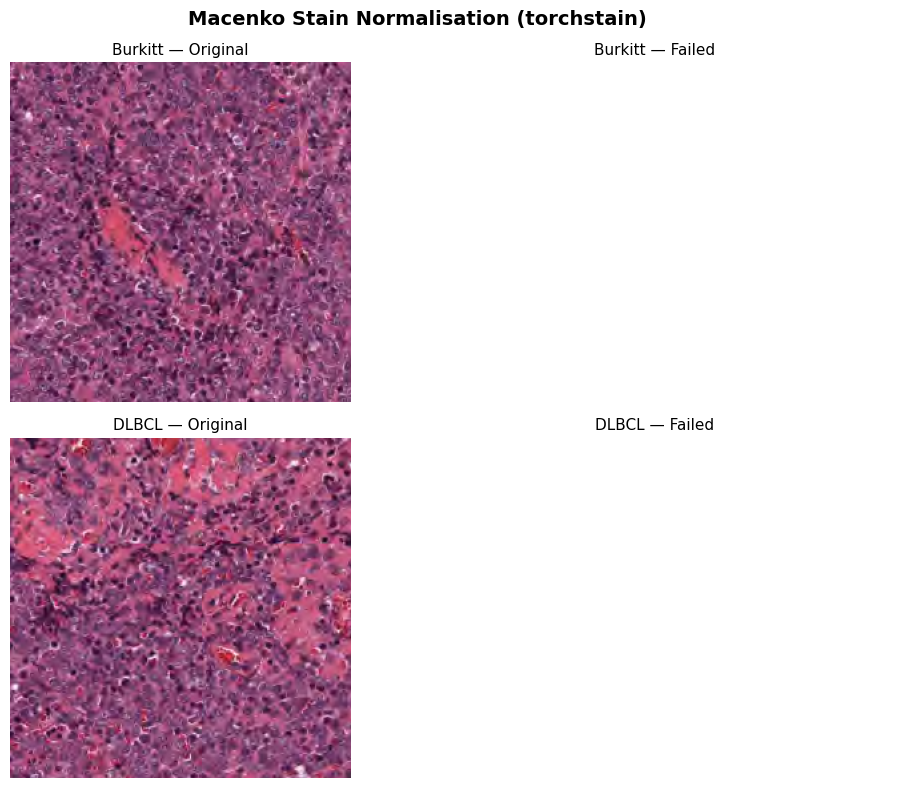

In [17]:
# Step 2 — Test torchstain on one patch from each class
import torchstain
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
import os

# torchstain expects tensors in range [0, 255]
to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 255)
])

# Pick reference patch from training set — a clean well-stained burkitt patch
reference_path = train_samples[0][0]
reference_image = Image.open(reference_path).convert("RGB")
reference_tensor = to_tensor(reference_image)

# Fit normaliser to reference
normalizer = torchstain.normalizers.MacenkoNormalizer(backend="torch")
normalizer.fit(reference_tensor)
print(f"Normaliser fitted to: {os.path.basename(reference_path)}")

# Test on one burkitt and one dlbcl patch
burkitt_path = train_samples[50][0]
dlbcl_path   = [(p, l) for p, l in train_samples if l == 1][50][0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row, (path, label) in enumerate([(burkitt_path, "Burkitt"), (dlbcl_path, "DLBCL")]):
    img = Image.open(path).convert("RGB")
    img_tensor = to_tensor(img)

    try:
        normalized_tensor, _, _ = normalizer.normalize(img_tensor, stains=False)
        normalized_img = Image.fromarray(normalized_tensor.byte().permute(1, 2, 0).numpy())
        norm_failed = False
    except Exception as e:
        print(f"  Normalisation failed for {label}: {e}")
        norm_failed = True

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{label} — Original", fontsize=11)
    axes[row, 0].axis("off")

    if not norm_failed:
        axes[row, 1].imshow(normalized_img)
        axes[row, 1].set_title(f"{label} — Normalised", fontsize=11)
    else:
        axes[row, 1].set_title(f"{label} — Failed", fontsize=11)
    axes[row, 1].axis("off")

plt.suptitle("Macenko Stain Normalisation (torchstain)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()